In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models,Sequential
import os

In [3]:
data_path='/content/drive/My Drive/Wafer data/Wafers'
data=os.listdir(data_path)
print(data)
image_ds=tf.keras.preprocessing.image_dataset_from_directory(data_path,image_size=(256,256),batch_size=32)

['Scratch', 'random', 'near full', 'none', 'Local', 'Edge Ring', 'Donut', 'Edge Local', 'Center']
Found 901 files belonging to 9 classes.


In [4]:
train_ds=image_ds.take(int(0.8*len(image_ds)))
rem_ds=image_ds.skip(int(0.8*len(image_ds)))
test_ds=rem_ds.take(int(0.5*len(rem_ds)))
val_ds=rem_ds.skip(int(0.5*len(rem_ds)))

In [5]:
class_name=image_ds.class_names

In [6]:
auto=tf.data.AUTOTUNE
train_ds=train_ds.cache().prefetch(buffer_size=auto)
val_ds=val_ds.cache().prefetch(buffer_size=auto)

In [7]:
resize=Sequential([
    layers.Rescaling(1./255,input_shape=(256,256,3))
])
flip=Sequential([
    layers.RandomFlip(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model=Sequential([
    resize,
    flip,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(len(class_name),activation='softmax'),
    layers.Dropout(0.2)



])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [12]:
history=model.fit(train_ds,epochs=50,validation_data=val_ds)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 159s 7s/step - accuracy: 0.1943 - loss: 4.8754 - val_accuracy: 0.2464 - val_loss: 1.9055
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3166 - loss: 4.1734 - val_accuracy: 0.4783 - val_loss: 1.5725
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3818 - loss: 4.5601 - val_accuracy: 0.5942 - val_loss: 1.1550
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4769 - loss: 3.8636 - val_accuracy: 0.6377 - val_loss: 1.0115
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5177 - loss: 3.7117 - val_accuracy: 0.6957 - val_loss: 0.7851
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5448 - loss: 3.3555 - val_accuracy: 0.6957 - val_loss: 0.8565
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5408 - loss: 3.2404 - val_accuracy: 0.8406 - val_loss: 0.7144
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5747 - loss: 3.3446 - val_accuracy: 0.8261 - v

In [16]:
import numpy as np
y_true=[]
y_pred=[]

In [17]:
for images,labels in val_ds:
  preds=model.predict(images)
  pred_labels = np.argmax(preds, axis=1)
  y_true.extend(labels.numpy())
  y_pred.extend(pred_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred,target_names=class_name))

              precision    recall  f1-score   support

      Center       1.00      0.86      0.92         7
       Donut       1.00      1.00      1.00        12
  Edge Local       1.00      1.00      1.00         7
   Edge Ring       1.00      1.00      1.00         8
       Local       0.83      0.71      0.77         7
     Scratch       0.67      0.80      0.73         5
   near full       1.00      1.00      1.00         8
        none       1.00      1.00      1.00         8
      random       0.88      1.00      0.93         7

    accuracy                           0.94        69
   macro avg       0.93      0.93      0.93        69
weighted avg       0.95      0.94      0.94        69



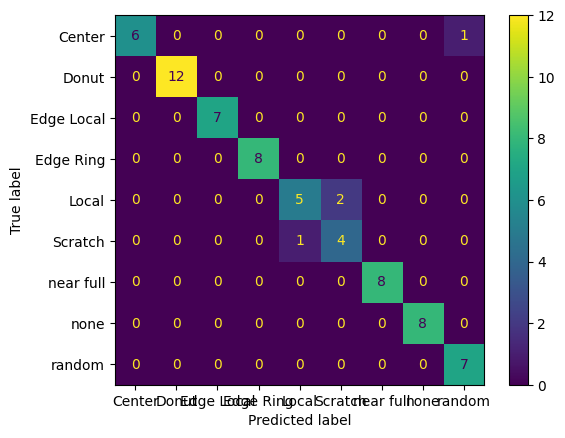

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_name)
disp.plot()
plt.show()

Transfer Learning

In [28]:
from tensorflow.keras.applications import MobileNetV2

In [29]:
base_model = MobileNetV2(
    input_shape=(256,256,3),
    include_top=False,
    weights='imagenet'
)

/tmp/ipykernel_6331/1379434242.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
base_model.trainable = False

In [39]:
from tensorflow.keras import models, layers

model2 = models.Sequential([
    resize,
    flip,

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_name), activation='softmax')
])

In [40]:
from tensorflow.keras.optimizers import Adam

model2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model2.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.1073 - loss: 2.4366 - val_accuracy: 0.2174 - val_loss: 2.1383
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.2242 - loss: 2.1112 - val_accuracy: 0.3043 - val_loss: 1.9337
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3302 - loss: 1.9240 - val_accuracy: 0.4203 - val_loss: 1.7909
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3641 - loss: 1.8177 - val_accuracy: 0.4928 - val_loss: 1.6843
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.4321 - loss: 1.7131 - val_accuracy: 0.5072 - val_loss: 1.5870
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4701 - loss: 1.6213 - val_accuracy: 0.5652 - val_loss: 1.5025
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4864 - loss: 1.5474 - val_accuracy: 0.6377 - val_loss: 1.4363
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5041 - loss: 1.4862 - val_accuracy: 0.6377 - 

In [43]:
y_true_1=[]
y_pred_1=[]
for images,labels in val_ds:
  preds=model2.predict(images)
  pred_labels = np.argmax(preds, axis=1)
  y_true_1.extend(labels.numpy())
  y_pred_1.extend(pred_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_true_1,y_pred_1,target_names=class_name))

              precision    recall  f1-score   support

      Center       0.67      0.57      0.62         7
       Donut       0.83      0.83      0.83        12
  Edge Local       0.71      0.71      0.71         7
   Edge Ring       0.80      1.00      0.89         8
       Local       1.00      0.71      0.83         7
     Scratch       0.83      1.00      0.91         5
   near full       0.89      1.00      0.94         8
        none       1.00      0.88      0.93         8
      random       0.86      0.86      0.86         7

    accuracy                           0.84        69
   macro avg       0.84      0.84      0.84        69
weighted avg       0.85      0.84      0.84        69

